# 🔬 BioSLATE Phase 3 — Synthetic Lethal Target Discovery (HGSOC)

**Author:** Faith Ogundimu  
**Date:** July 24th 2025

__Notebook Purpose__
To identify context-specific synthetic lethal (SL) dependencies in HGSOC cell lines using DepMap CRISPR data.

__Methods Tried__
- **Welch’s t-test**: initial method to compare gene dependency between biomarker-positive vs wild-type lines.
- **OLS Linear Regression**: final method, modelling gene dependency as a function of biomarker CNA status, with effect size estimated from predicted dependency at CNA=2 vs CNA=6.

__Config Highlights__
- Biomarkers: CNA-amplified genes validated in both TCGA and DepMap.
- Clustering: Biomarkers with identical CNA profiles grouped into clusters.
- Representative gene per cluster selected via **CrewAI agent**, ranked by SL/cancer relevance and druggability (see agents/cluster_selector_agent.py).
- **Manual override** applied for key oncogenes (e.g. CCNE1, KRAS, MYC, MECOM) to ensure biological plausibility.

__Output Per Pair__
- FDR, effect size (Δ CNA6 vs CNA2), regression stats
- Filters for context-specificity (≥6 lines, target not essential in WT)

## Step 1A: Define Screening Configurations

In this block, we define the hyperparameters for each SL screening strategy.

Each config includes:
- `amp_threshold`: Minimum CNA value to define "Amplified"
- `wt_values`: CNA values considered as "WT"
- `cluster`: Whether to collapse biomarkers with identical AMP/WT profiles
- `name`: Used to name output folders and identify runs

In [35]:
# Required packages
import pandas as pd
import numpy as np

# Load input datasets:
## AMP biomarkers
amp_biomarkers = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/results/cross_val_amp_sig_genes.csv", index_col=1)
amp_biomarkers = amp_biomarkers.index.astype(str)
amp_biomarkers

## CNA DepMap
cna_hgsoc_depmap = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/results/cna_depmap_hgsoc.csv", index_col=0)
cna_hgsoc_depmap = cna_hgsoc_depmap.transpose()
cna_hgsoc_depmap_filtered = cna_hgsoc_depmap.loc[amp_biomarkers]
cna_hgsoc_depmap_filtered = cna_hgsoc_depmap_filtered.transpose()

## CRISPR
crispr_filtered = pd.read_csv("../streamlit_app/data/crispr_for_streamlit.csv", index_col=0) 

In [63]:
configs = []

wt_variants = [
    [2],
    [1, 2],
    [2, 3],
    [0, 1, 2],
    [0, 1, 2, 3],
    [0, 1, 2, 3, 4],
    [0, 1, 2, 3, 4, 5]
]

for wt in wt_variants:
    for cluster in [True]: # changed to True only for quickness
        label = "_".join(map(str, wt))
        cluster_tag = "Clustered" if cluster else "NoCluster"
        config = {
            "name": f"CNA6_WT{label}_{cluster_tag}",
            "amp_threshold": 6,
            "wt_values": wt,
            "cluster": cluster
        }
        configs.append(config)

## Step 2A: Define the Synthetic Lethality Screening Function (T-Test Function)

This function runs the full SL screening pipeline for a single configuration:
- Assigns CNA-based Amplified/WT status for each biomarker gene across cell lines
- Optionally collapses redundant biomarkers using CNA profile clustering
- Performs two-sample Welch’s t-tests comparing CRISPR gene effect scores between Amplified vs WT groups
- Calculates effect size (Cohen’s d) for each biomarker–target pair
- Applies multiple testing correction using Benjamini–Hochberg FDR
- Filters results based on significance (p-value < 0.05), FDR (< 0.1), effect size (< 0), and WT selectivity (> –1)
- Saves all result tables into a dedicated folder named after the config

The function returns a summary dictionary reporting the number of tests performed and the number of hits at various filtering stages.

In [64]:
import os
from collections import defaultdict
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

def run_sl_screen(config, amp_biomarkers, cna_df, crispr_df, out_root="../results"):
    amp_threshold = config["amp_threshold"]
    wt_values = config["wt_values"]
    cluster = config["cluster"]
    name = config["name"]

    out_dir = os.path.join(out_root, name)
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(os.path.join(out_dir, "other"), exist_ok=True)

    status_dict = {}
    for gene in amp_biomarkers:
        if gene in cna_df.columns:
            status_dict[gene] = cna_df[gene].apply(
                lambda x: "Amplified" if x >= amp_threshold else ("WT" if x in wt_values else np.nan)
            )
    status_df = pd.DataFrame(status_dict, index=cna_df.index)

    if cluster:
        profile_groups = defaultdict(list)
        for gene in status_df.columns:
            profile = tuple(status_df[gene].fillna("NA").values)
            profile_groups[profile].append(gene)
        biomarker_sets = [ (group[0], ", ".join(sorted(group))) for group in profile_groups.values() ]
    else:
        biomarker_sets = [ (gene, gene) for gene in status_df.columns ]

    results = []
    for rep_gene, alias in biomarker_sets:
        if rep_gene not in status_df:
            continue

        status = status_df[rep_gene]
        amp_lines = status[status == "Amplified"].index.intersection(crispr_df.index)
        wt_lines = status[status == "WT"].index.intersection(crispr_df.index)

        if len(amp_lines) < 3 or len(wt_lines) < 3:
            continue

        for target in crispr_df.columns:
            if not (crispr_df[target] < -0.6).any():
                continue

            group_amp = crispr_df.loc[amp_lines, target].dropna()
            group_wt = crispr_df.loc[wt_lines, target].dropna()
            if len(group_amp) < 3 or len(group_wt) < 3:
                continue

            t_stat, p_val = ttest_ind(group_amp, group_wt, equal_var=False)
            pooled_sd = np.sqrt(((group_amp.std(ddof=1)**2 + group_wt.std(ddof=1)**2) / 2))
            effect_size = (group_amp.mean() - group_wt.mean()) / pooled_sd if pooled_sd > 0 else np.nan

            results.append({
                "Biomarker": rep_gene,
                "BiomarkerCluster": alias,
                "TargetGene": target,
                "OncogeneAddiction": rep_gene == target,
                "T-stat": t_stat,
                "P-value": p_val,
                "EffectSize": effect_size,
                "n_Amplified": len(group_amp),
                "n_WT": len(group_wt),
                "MeanEffect_Amplified": group_amp.mean(),
                "MeanEffect_WT": group_wt.mean()
            })

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df["FDR"] = multipletests(results_df["P-value"], method="fdr_bh")[1]
    else:
        results_df["FDR"] = []

    results_df.to_csv(f"{out_dir}/synthetic_lethality_screen.csv", index=False)

    pval_hits = results_df[results_df["P-value"] < 0.05]
    pval_hits.to_csv(f"{out_dir}/other/significant_synthetic_hits_pval.csv", index=False)

    fdr_hits = results_df[results_df["FDR"] < 0.1]
    fdr_hits.to_csv(f"{out_dir}/other/significant_synthetic_hits_fdr.csv", index=False)

    strong_hits = fdr_hits[fdr_hits["EffectSize"] < 0]
    strong_hits.to_csv(f"{out_dir}/strong_synthetic_lethal_hits.csv", index=False)

    selective_hits = strong_hits[strong_hits["MeanEffect_WT"] > -1]
    selective_hits.to_csv(f"{out_dir}/selective_synthetic_lethal_hits.csv", index=False)

    return {
        "ConfigName": name,
        "SLTests": len(results_df),
        "FDRHits": len(fdr_hits),
        "StrongHits": len(strong_hits),
        "SelectiveHits": len(selective_hits)
    }


## Step 3: Run All Configurations and Collect Summary Stats

This loop:
- Runs `run_sl_screen()` for each config in the list
- Prints which config is currently running
- Stores the summary stats (e.g. number of SL tests, FDR hits, etc.)
- Outputs a `summary_df` DataFrame showing comparative results
- Saves the summary to a CSV for downstream reporting

Expect each config to take a few seconds to run depending on your biomarker and CRISPR data size.

In [65]:
summary = []

for cfg in configs:
    print(f"Running config: {cfg['name']}")
    result = run_sl_screen(cfg, amp_biomarkers, cna_hgsoc_depmap_filtered, crispr_filtered)
    summary.append(result)

summary_df = pd.DataFrame(summary)
summary_df.to_csv("../results/sl_screen_summary.csv", index=False)
summary_df

Running config: CNA6_WT2_Clustered
Running config: CNA6_WT1_2_Clustered
Running config: CNA6_WT2_3_Clustered
Running config: CNA6_WT0_1_2_Clustered
Running config: CNA6_WT0_1_2_3_Clustered
Running config: CNA6_WT0_1_2_3_4_Clustered


KeyboardInterrupt: 

## Step 4: Add HGNC Gene Symbols to SL Results

This step maps Entrez Gene IDs in the `Biomarker` and `TargetGene` columns to their official HGNC gene symbols using the `gene_with_protein_product.txt` reference file.

The HGNC names are inserted directly beside each ID column in both:
- `strong_synthetic_lethal_hits.csv`
- `selective_synthetic_lethal_hits.csv`

Updated files are saved with `_with_HGNC` suffix in the `../results/` folder.


In [59]:
import pandas as pd

# Load your result files
sl_hits_strong = pd.read_csv("../results/T-Test/CNA6_WTlt6_Clustered/strong_synthetic_lethal_hits.csv")
sl_hits_selective = pd.read_csv("../results/T-Test/CNA6_WTlt6_Clustered/selective_synthetic_lethal_hits.csv")

# Load the HGNC mapping file
hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")

# Build a mapping: Entrez ID (as string) → HGNC symbol
entrez_to_symbol = dict(zip(hgnc_df["entrez_id"].astype(str), hgnc_df["symbol"]))

# Function to insert HGNC symbols beside original columns
def insert_hgnc_columns(df):
    df.insert(
        loc=df.columns.get_loc("Biomarker") + 1,
        column="Biomarker_HGNC",
        value=df["Biomarker"].apply(lambda x: entrez_to_symbol.get(str(x)))
    )

    df.insert(
        loc=df.columns.get_loc("TargetGene") + 1,
        column="TargetGene_HGNC",
        value=df["TargetGene"].apply(lambda x: entrez_to_symbol.get(str(x)))
    )

    df.insert(
        loc=df.columns.get_loc("BiomarkerCluster") + 1,
        column="BiomarkerCluster_HGNC",
        value=df["BiomarkerCluster"].apply(
            lambda cluster: ", ".join([
                entrez_to_symbol.get(gid.strip(), "NA")
                for gid in cluster.split(",")
            ])
        )
    )
    return df

# Apply to both DataFrames
sl_hits_strong = insert_hgnc_columns(sl_hits_strong)
sl_hits_selective = insert_hgnc_columns(sl_hits_selective)

# Save updated files
sl_hits_strong.to_csv("../results/T-Test/CNA6_WTlt6_Clustered/strong_synthetic_lethal_hits_with_HGNC.csv", index=False)
sl_hits_selective.to_csv("../results/T-Test/CNA6_WTlt6_Clustered/selective_synthetic_lethal_hits_with_HGNC.csv", index=False)

/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_7466/920875569.py:8: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")


## Step 1B: Define Screening Configurations

In this block, we define the hyperparameters for each SL screening strategy.

Each config includes:
- `amp_threshold`: Minimum CNA value to define "Amplified"
- `wt_values`: CNA values considered as "WT"
- `cluster`: Whether to collapse biomarkers with identical AMP/WT profiles
- `name`: Used to name output folders and identify runs

In [90]:
configs = [
    {"name": "CNA_quantitative"}
]


## Step 2B: Define the Synthetic Lethality Screening Function (Quantitative CNA Regression)

This function executes the SL screening pipeline using continuous CNA values as predictors in a linear regression framework:

* For each biomarker gene, raw copy number values (continuous) across cell lines are used directly as predictors.
* No discrete binning into 'Amplified' or 'WT' — the model assesses the quantitative relationship between CNA and CRISPR gene dependency.
* For every biomarker–target gene pair:

  * Fits an OLS linear regression: `CRISPR_dependency ~ CNA_value`
  * Computes the regression β coefficient, reflecting the change in gene effect score per unit increase in CNA.
  * Uses HC3 robust standard errors to account for heteroskedasticity (unequal variance across cell lines).
  * Extracts confidence intervals, p-values, and standardised effect size (β / SD of response).
  * Predicts dependency score at CNA = 2 to evaluate selectivity.

* Applies Benjamini–Hochberg FDR correction on p-values.

* Applies final hit filters:

  * **p < 0.05**
  * **FDR < 0.1**
  * **Negative effect size (β < 0)** — consistent with increased dependency in amplified contexts
  * **Predicted dependency at CNA = 2 > –1** — avoids pan-essential genes

* Saves all results to a dedicated output folder per configuration.

The function returns a dictionary summarising:

* Total gene pairs tested
* FDR-significant hits
* Strong hits (β < 0)
* Selective hits (non-pan-essential) for downstream prioritisation.


In [77]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

def run_sl_screen(config, amp_biomarkers, cna_df, crispr_df, out_root="../results"):
    name = config["name"]

    out_dir = os.path.join(out_root, name)
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(os.path.join(out_dir, "other"), exist_ok=True)

    # Use continuous CNA directly
    status_df = cna_df[amp_biomarkers.intersection(cna_df.columns)]
    biomarker_sets = [(gene, gene) for gene in status_df.columns]

    results = []
    for rep_gene in biomarker_sets:
        if rep_gene not in cna_df.columns:
            continue

        cna_vector = cna_df[rep_gene].dropna()
        common_lines = cna_vector.index.intersection(crispr_df.index)

        if len(common_lines) < 6:
            continue

        cna_vector = cna_vector.loc[common_lines]

        for target in crispr_df.columns:
            dep_vector = crispr_df[target].loc[common_lines].dropna()
            matched = dep_vector.index.intersection(cna_vector.index)

            if len(matched) < 6:
                continue

            # Require at least one strongly dependent cell line
            if not (dep_vector.loc[matched] < -0.6).any():
                continue

            X = sm.add_constant(cna_vector.loc[matched])
            y = dep_vector.loc[matched]

            try:
                model = sm.OLS(y, X).fit(cov_type="HC3")
                beta = model.params.iloc[1]
                p_val = model.pvalues.iloc[1]
                t_stat = model.tvalues.iloc[1]
                conf_int = model.conf_int().iloc[1]
                effect_size = beta / y.std(ddof=1) if y.std(ddof=1) > 0 else np.nan
                predicted_at_cna2 = model.predict([1, 2])[0]
            except:
                continue

            results.append({
                "Biomarker": rep_gene,
                "TargetGene": target,
                "OncogeneAddiction": rep_gene == target,
                "Beta": beta,
                "T-stat": t_stat,
                "P-value": p_val,
                "EffectSize": effect_size,
                "CI_Lower": conf_int[0],
                "CI_Upper": conf_int[1],
                "n_Lines": len(matched),
                "MeanCNA": cna_vector.loc[matched].mean(),
                "MeanEffect": y.mean(),
                "PredictedEffect_CNA2": predicted_at_cna2
            })

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df["FDR"] = multipletests(results_df["P-value"], method="fdr_bh")[1]
    else:
        results_df["FDR"] = []

    results_df.to_csv(f"{out_dir}/synthetic_lethality_screen.csv", index=False)

    pval_hits = results_df[results_df["P-value"] < 0.05]
    pval_hits.to_csv(f"{out_dir}/other/significant_synthetic_hits_pval.csv", index=False)

    fdr_hits = results_df[results_df["FDR"] < 0.1]
    fdr_hits.to_csv(f"{out_dir}/other/significant_synthetic_hits_fdr.csv", index=False)

    strong_hits = fdr_hits[fdr_hits["EffectSize"] < 0]
    strong_hits.to_csv(f"{out_dir}/strong_synthetic_lethal_hits.csv", index=False)

    selective_hits = strong_hits[strong_hits["PredictedEffect_CNA2"] > -1]
    selective_hits.to_csv(f"{out_dir}/selective_synthetic_lethal_hits.csv", index=False)

    return {
        "ConfigName": name,
        "SLTests": len(results_df),
        "FDRHits": len(fdr_hits),
        "StrongHits": len(strong_hits),
        "SelectiveHits": len(selective_hits)
    }


## Step 2C: Handling Potential Co-Amplification Confounding

To avoid false positives from genes that are co-amplified together across cell lines:

* **Exact CNA profile clustering** is used:

  * Genes with *identical* CNA values across all profiled cell lines are grouped into a cluster.
  * Only one gene (the first) is retained as the representative biomarker per cluster.
  * This avoids redundancy when multiple genes share indistinguishable CNA patterns.

* This is a strict filter — it **does not** capture biologically co-amplified genes unless their profiles are identical.

* For broader co-amplification handling:

  * Consider computing **pairwise CNA correlations** across biomarkers.
  * Filter or annotate hits where biomarker–target pairs are frequently **co-amplified** in the same cell lines.

This step helps reduce artificial hits due to shared amplification patterns rather than genuine synthetic lethality.


In [98]:
configs = [
    {"name": "CNA_quantitative_cluster_delta"}
]

In [99]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from collections import defaultdict

def run_sl_screen(config, amp_biomarkers, cna_df, crispr_df, out_root="../results"):
    name = config["name"]

    out_dir = os.path.join(out_root, name)
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(os.path.join(out_dir, "other"), exist_ok=True)

    # Use continuous CNA directly
    status_df = cna_df[amp_biomarkers.intersection(cna_df.columns)]

    # Cluster biomarkers with identical CNA profiles
    profile_groups = defaultdict(list)
    for gene in status_df.columns:
        profile = tuple(status_df[gene].fillna("NA").values)
        profile_groups[profile].append(gene)
    biomarker_sets = [(group[0], ", ".join(sorted(group))) for group in profile_groups.values()]

    results = []
    for rep_gene, cluster_str in biomarker_sets:
        if rep_gene not in cna_df.columns:
            continue

        cna_vector = cna_df[rep_gene].dropna()
        common_lines = cna_vector.index.intersection(crispr_df.index)

        if len(common_lines) < 6:
            continue

        cna_vector = cna_vector.loc[common_lines]

        for target in crispr_df.columns:
            dep_vector = crispr_df[target].loc[common_lines].dropna()
            matched = dep_vector.index.intersection(cna_vector.index)

            if len(matched) < 6:
                continue

            # Require at least one strongly dependent cell line
            if not (dep_vector.loc[matched] < -0.6).any():
                continue

            X = sm.add_constant(cna_vector.loc[matched])
            y = dep_vector.loc[matched]

            try:
                model = sm.OLS(y, X).fit(cov_type="HC3")
                beta = model.params.iloc[1]
                p_val = model.pvalues.iloc[1]
                t_stat = model.tvalues.iloc[1]
                conf_int = model.conf_int().iloc[1]
                effect_size = beta / y.std(ddof=1) if y.std(ddof=1) > 0 else np.nan
                predicted_at_cna2 = model.predict([1, 2])[0]

                # Mean effect in samples where CNA ≥ 6
                high_amp_lines = cna_vector[cna_vector >= 6].index
                mean_effect_amp6plus = y.loc[high_amp_lines].mean() if not y.loc[high_amp_lines].empty else np.nan

                delta = mean_effect_amp6plus - predicted_at_cna2 if pd.notnull(mean_effect_amp6plus) else np.nan
            except:
                continue

            results.append({
                "Biomarker": rep_gene,
                "BiomarkerCluster": cluster_str,
                "TargetGene": target,
                "OncogeneAddiction": rep_gene == target,
                "Beta": beta,
                "T-stat": t_stat,
                "P-value": p_val,
                "EffectSize": effect_size,
                "CI_Lower": conf_int[0],
                "CI_Upper": conf_int[1],
                "n_Lines": len(matched),
                "MeanCNA": cna_vector.loc[matched].mean(),
                "MeanEffect": y.mean(),
                "MeanEffect_CNA6plus": mean_effect_amp6plus,
                "PredictedEffect_CNA2": predicted_at_cna2,
                "DeltaEffect_CNA6minusPred2": delta
            })

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df["FDR"] = multipletests(results_df["P-value"], method="fdr_bh")[1]
    else:
        results_df["FDR"] = []

    results_df.to_csv(f"{out_dir}/synthetic_lethality_screen.csv", index=False)

    pval_hits = results_df[results_df["P-value"] < 0.05]
    pval_hits.to_csv(f"{out_dir}/other/significant_synthetic_hits_pval.csv", index=False)

    fdr_hits = results_df[results_df["FDR"] < 0.05]
    fdr_hits.to_csv(f"{out_dir}/other/significant_synthetic_hits_fdr.csv", index=False)

    strong_hits = fdr_hits[fdr_hits["EffectSize"] < 0]
    strong_hits.to_csv(f"{out_dir}/strong_synthetic_lethal_hits.csv", index=False)

    selective_hits = strong_hits[strong_hits["PredictedEffect_CNA2"] > -1]
    selective_hits.to_csv(f"{out_dir}/selective_synthetic_lethal_hits.csv", index=False)

    return {
        "ConfigName": name,
        "SLTests": len(results_df),
        "FDRHits": len(fdr_hits),
        "StrongHits": len(strong_hits),
        "SelectiveHits": len(selective_hits)
    }

## Step 3: Run All Configurations and Collect Summary Stats

This loop:
- Runs `run_sl_screen()` for each config in the list
- Prints which config is currently running
- Stores the summary stats (e.g. number of SL tests, FDR hits, etc.)
- Outputs a `summary_df` DataFrame showing comparative results
- Saves the summary to a CSV for downstream reporting

Expect each config to take a few seconds to run depending on your biomarker and CRISPR data size.

In [100]:
summary = []

for cfg in configs:
    print(f"Running config: {cfg['name']}")
    result = run_sl_screen(cfg, amp_biomarkers, cna_hgsoc_depmap_filtered, crispr_filtered)
    summary.append(result)

summary_df = pd.DataFrame(summary)
summary_df.to_csv("../results/sl_screen_summary.csv", index=False)
summary_df

Running config: CNA_quantitative_cluster_delta


,ConfigName,SLTests,FDRHits,StrongHits,SelectiveHits
0,CNA_quantitative_cluster_delta,521374,3476,1601,1075


## Filter to Most Potent Hits

In [48]:
oncogene_addict_counts = pd.read_csv("../results/CNA_quantitative_cluster_delta/synthetic_lethality_screen_with_HGNC.csv")

# Count number of oncogene addictions.
oncogene_addict_counts = oncogene_addict_counts["OncogeneAddiction"].sum()
oncogene_addict_counts

# "OncogeneAddiction" is already a Boolean column.
# .sum() on a Boolean Series counts how many True values exist.

/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_43025/307696192.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  oncogene_addict_counts = pd.read_csv("../results/CNA_quantitative_cluster_delta/synthetic_lethality_screen_with_HGNC.csv")


70

In [14]:
import pandas as pd

selective_hits = pd.read_csv("../results/CNA_quantitative_cluster_delta/selective_synthetic_lethal_hits.csv")

# Define the exact desired column order
desired_order = [
    'Biomarker', 'BiomarkerCluster', 'TargetGene', 'OncogeneAddiction',
    'Beta', 'T-stat', 'P-value', 'EffectSize', 'CI_Lower', 'CI_Upper',
    'n_Lines', 'MeanCNA', 'MeanEffect',
    'MeanEffect_CNA6plus',  # <-- moved here
    'PredictedEffect_CNA2',  # <-- comes after
    'DeltaEffect_CNA6minusPred2',
    'FDR'
]

# Reorder
selective_hits = selective_hits[desired_order]
selective_hits

,Biomarker,BiomarkerCluster,TargetGene,OncogeneAddiction,Beta,T-stat,P-value,EffectSize,CI_Lower,CI_Upper,n_Lines,MeanCNA,MeanEffect,MeanEffect_CNA6plus,PredictedEffect_CNA2,DeltaEffect_CNA6minusPred2,FDR
0,10016,"10016, 11336",10480,False,-0.118552,-3.867643,1.098923e-04,-0.499304,-0.178629,-0.058475,17,4.058824,-1.154748,-1.517690,-0.910671,-0.607019,2.253932e-02
1,1004,"1004, 55322",7849,False,-0.197322,-4.376055,1.208464e-05,-0.301321,-0.285699,-0.108945,17,3.941176,-0.915860,-1.356943,-0.532824,-0.824120,4.393152e-03
2,1004,"1004, 55322",8467,False,-0.097358,-6.090735,1.123935e-09,-0.474773,-0.128687,-0.066029,17,3.941176,-0.458666,-0.705696,-0.269677,-0.436018,1.878175e-06
3,1004,"1004, 55322",7328,False,-0.115045,-3.915591,9.018315e-05,-0.358058,-0.172631,-0.057459,17,3.941176,-0.482106,-0.864307,-0.258783,-0.605524,1.945707e-02
4,10051,"10051, 3840, 51068, 8706",132660,False,-0.102927,-4.284172,1.834207e-05,-0.379547,-0.150015,-0.055839,17,4.588235,-0.290486,-0.573911,-0.024086,-0.549825,5.870519e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070,9846,9846,9804,False,-0.042765,-5.147339,2.642076e-07,-0.174569,-0.059049,-0.026481,17,5.097063,-0.616260,-0.934759,-0.483814,-0.450945,2.037736e-04
1071,9846,9846,163131,False,-0.057176,-7.890749,3.003784e-15,-0.261418,-0.071378,-0.042974,17,5.097063,-0.126525,-0.361195,0.050554,-0.411748,1.614531e-11
1072,9847,9847,55140,False,-0.117945,-3.911726,9.163899e-05,-0.358267,-0.177041,-0.058849,17,4.000000,-0.839405,-1.161180,-0.603516,-0.557664,1.967800e-02
1073,9847,9847,132660,False,-0.103511,-4.398658,1.089224e-05,-0.381700,-0.149633,-0.057388,17,4.000000,-0.290486,-0.573911,-0.083464,-0.490447,4.085562e-03


In [17]:
potent_hits = selective_hits[
    (selective_hits["DeltaEffect_CNA6minusPred2"] <= -0.5) &
    (selective_hits["PredictedEffect_CNA2"] >= -0.6)
]

potent_hits.to_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits.csv", index=False)

## Step 4: Add HGNC Gene Symbols to SL Results

This step maps Entrez Gene IDs in the `Biomarker` and `TargetGene` columns to their official HGNC gene symbols using the `gene_with_protein_product.txt` reference file.

The HGNC names are inserted directly beside each ID column in both:
- `strong_synthetic_lethal_hits.csv`
- `selective_synthetic_lethal_hits.csv`

Updated files are saved with `_with_HGNC` suffix in the `../results/` folder.


In [18]:
import pandas as pd

# Load your result files
sl_hits_potent = pd.read_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits.csv")

# Load the HGNC mapping file
hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")

# Build a mapping: Entrez ID (as string) → HGNC symbol
entrez_to_symbol = dict(zip(hgnc_df["entrez_id"].astype(str), hgnc_df["symbol"]))

# Function to insert HGNC symbols beside original columns
def insert_hgnc_columns(df):
    df.insert(
        loc=df.columns.get_loc("Biomarker") + 1,
        column="Biomarker_HGNC",
        value=df["Biomarker"].apply(lambda x: entrez_to_symbol.get(str(x)))
    )

    df.insert(
        loc=df.columns.get_loc("TargetGene") + 1,
        column="TargetGene_HGNC",
        value=df["TargetGene"].apply(lambda x: entrez_to_symbol.get(str(x)))
    )

    df.insert(
        loc=df.columns.get_loc("BiomarkerCluster") + 1,
        column="BiomarkerCluster_HGNC",
        value=df["BiomarkerCluster"].apply(
            lambda cluster: ", ".join([
                entrez_to_symbol.get(gid.strip(), "NA")
                for gid in cluster.split(",")
            ])
        )
    )
    return df

# Apply to DataFrame
sl_hits_potent = insert_hgnc_columns(sl_hits_potent)

# Save updated files
sl_hits_potent.to_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv", index=False)

/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_43025/1777138762.py:7: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")


## Clean Hits for Agent

In [20]:
import pandas as pd

# Load your full potent hits file
input_file = "../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv"
df = pd.read_csv(input_file)

# Extract required columns for the agent
agent_input_df = df[["BiomarkerCluster_HGNC", "TargetGene_HGNC"]].copy()

# Save for agent use
output_file = "../agents/assets/cluster_hits.csv"
agent_input_df.to_csv(output_file, index=False)

print(f"Cleaned agent input saved to: {output_file}")

Cleaned agent input saved to: ../agents/assets/cluster_hits.csv


### Altering Representative Biomarker based on Agent

In [32]:
import pandas as pd

# Load files
sl_hits = pd.read_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv")
reps = pd.read_csv("../agents/cluster_selector/representative_biomarkers.csv")

# Map: cluster → representative gene
cluster_to_rep = dict(zip(reps["BiomarkerCluster_HGNC"], reps["ClusterRepresentative"]))

# Replace biomarker with representative
sl_hits["Biomarker_HGNC"] = sl_hits["BiomarkerCluster_HGNC"].map(cluster_to_rep)

# Save
sl_hits.to_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv", index=False)

## New Oncogene Addiction Detection

## Step 5: Visualising Regression-Based Synthetic Lethality Hits

This section presents key visualisations to interpret the output of the SL regression screen.

- **Volcano Plot**: Displays the global landscape of biomarker–target interactions by effect size and statistical confidence.
- **Regression Scatterplots**: Show model fit for individual top hits, illustrating the relationship between biomarker CNA and target dependency.
- **Heatmap**: Summarises gene effect scores of selected SL targets across HGSOC cell lines, highlighting context-specific vulnerabilities.

/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_43025/965481891.py:7: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../results/CNA_quantitative_cluster_delta/synthetic_lethality_screen.csv")


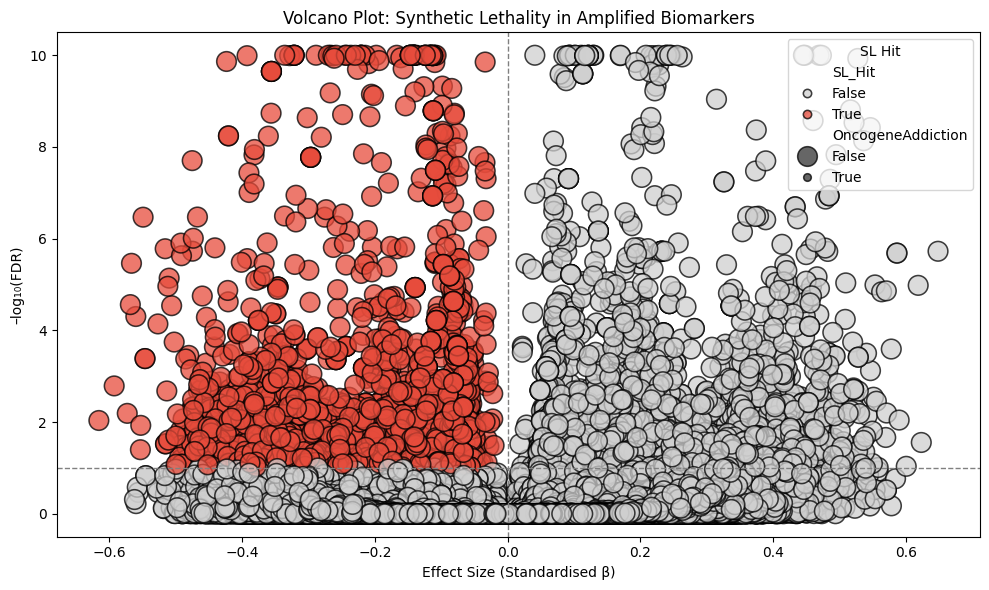

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load hits
df = pd.read_csv("../results/CNA_quantitative_cluster_delta/synthetic_lethality_screen.csv")

# Add -log10(FDR) and SL hit status
df["–log10(FDR)"] = -np.log10(df["FDR"] + 1e-10)  # avoid log(0)
df["SL_Hit"] = (df["EffectSize"] < 0) & (df["FDR"] < 0.1)
df["OncogeneAddiction"] = df["Biomarker"] == df["TargetGene"]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="EffectSize",
    y="–log10(FDR)",
    hue="SL_Hit",
    size="OncogeneAddiction",
    sizes=(30, 200),
    palette={True: "#e74c3c", False: "#d0d0d0"},
    alpha=0.75,
    edgecolor="black"
)

plt.axhline(y=-np.log10(0.1), linestyle="--", color="gray", linewidth=1)
plt.axvline(x=0, linestyle="--", color="gray", linewidth=1)
plt.xlabel("Effect Size (Standardised β)")
plt.ylabel("–log₁₀(FDR)")
plt.title("Volcano Plot: Synthetic Lethality in Amplified Biomarkers")
plt.legend(title="SL Hit", loc="upper right")
plt.tight_layout()
plt.show()

In [28]:
### add hgnc column to complete synthetic lethal screen csv

import pandas as pd

# Load your result files
sl_screen = pd.read_csv("../results/CNA_quantitative_cluster_delta/synthetic_lethality_screen.csv")

# Load the HGNC mapping file
hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")

# Build a mapping: Entrez ID (as string) → HGNC symbol
entrez_to_symbol = dict(zip(hgnc_df["entrez_id"].astype(str), hgnc_df["symbol"]))

# Function to insert HGNC symbols beside original columns
def insert_hgnc_columns(df):
    df.insert(loc=df.columns.get_loc("Biomarker") + 1,
              column="Biomarker_HGNC",
              value=df["Biomarker"].apply(lambda x: entrez_to_symbol.get(str(x))))
    
    df.insert(loc=df.columns.get_loc("TargetGene") + 1,
              column="TargetGene_HGNC",
              value=df["TargetGene"].apply(lambda x: entrez_to_symbol.get(str(x))))
    return df

# Apply to both DataFrames
sl_screen = insert_hgnc_columns(sl_screen)

# Save updated files
sl_screen.to_csv("../results/CNA_quantitative_cluster_delta/synthetic_lethality_screen_with_HGNC.csv", index=False)


/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_43025/390793496.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  sl_screen = pd.read_csv("../results/CNA_quantitative_cluster_delta/synthetic_lethality_screen.csv")
/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_43025/390793496.py:9: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")


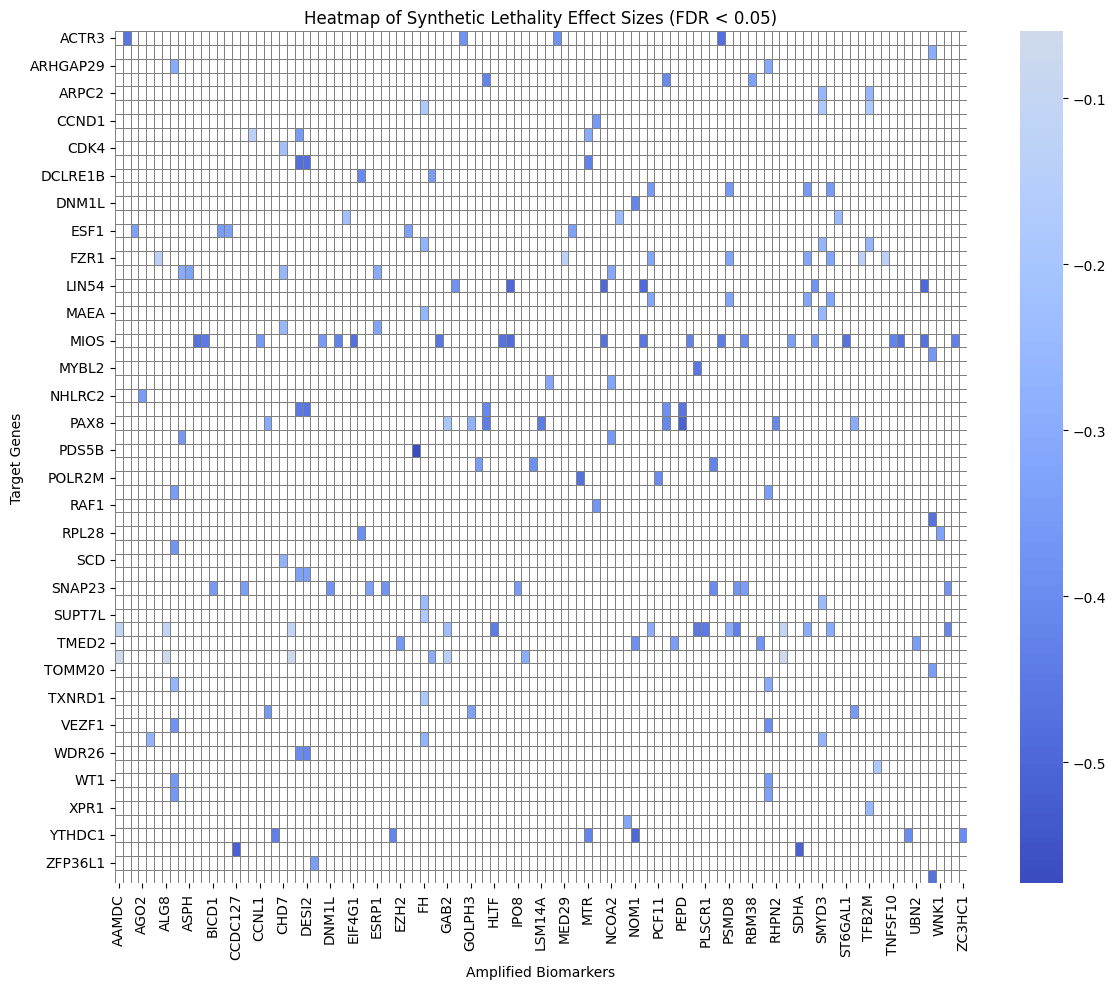

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load results
results_df = pd.read_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv")

# Pivot: rows = target genes, cols = biomarkers, values = Effect Size
heatmap_df = results_df.pivot(index="TargetGene_HGNC", columns="Biomarker_HGNC", values="EffectSize")

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_df, cmap="coolwarm", center=0, linewidths=0.5, linecolor="gray")
plt.title("Heatmap of Synthetic Lethality Effect Sizes (FDR < 0.05)")
plt.xlabel("Amplified Biomarkers")
plt.ylabel("Target Genes")
plt.tight_layout()
plt.show()

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os

# Set up plotting style
sns.set(style="whitegrid", context="notebook")
os.makedirs("../figures/sl_plots", exist_ok=True)

# Load matrices
cna_df = pd.read_csv("../results/cna_depmap_hgsoc.csv", index_col=0)
crispr_df = pd.read_csv("../results/crispr_hgsoc.csv", index_col=0)
cna_df.columns = cna_df.columns.astype(str)
crispr_df.columns = crispr_df.columns.astype(str)

# Load hits
df = pd.read_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv")
df["Biomarker"] = df["Biomarker"].astype(str)
df["TargetGene"] = df["TargetGene"].astype(str)

# Load HGNC mapping file (Entrez → HGNC)
hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t", dtype=str)
entrez_to_hgnc = dict(zip(hgnc_df["entrez_id"], hgnc_df["symbol"]))

# Plot
for idx, row in df[["Biomarker", "TargetGene"]].dropna().iterrows():
    biomarker = row["Biomarker"]
    target = row["TargetGene"]

    if biomarker not in cna_df.columns or target not in crispr_df.columns:
        print(f"Skipping {biomarker}–{target}: not found in matrix")
        continue

    x = cna_df[biomarker].dropna()
    y = crispr_df[target].dropna()
    common = x.index.intersection(y.index)

    if len(common) < 3:
        print(f"Skipping {biomarker}–{target}: not enough overlapping lines")
        continue

    r, p = pearsonr(x[common], y[common])

    # Map Entrez to HGNC for display (fallback to Entrez if missing)
    biomarker_label = entrez_to_hgnc.get(biomarker, biomarker)
    target_label = entrez_to_hgnc.get(target, target)

    plt.figure(figsize=(6, 4))
    sns.regplot(x=x[common], y=y[common],
                scatter_kws={"s": 50, "alpha": 0.8},
                line_kws={"color": "black", "linewidth": 1})

    plt.xlabel(f"{biomarker_label} CNA", fontsize=10)
    plt.ylabel(f"{target_label} Dependency Score", fontsize=10)
    plt.title(f"{biomarker_label} vs {target_label} Dependency\nr = {r:.2f}, p = {p:.4f}", fontsize=11)
    plt.tight_layout()

    # Save using HGNC names for readability (fallbacks handled)
    safe_name = f"{biomarker_label}_{target_label}".replace("/", "_")
    plt.savefig(f"../figures/sl_plots/{safe_name}_regression.png", dpi=300)
    plt.close()

### Getting Chromosomes for Hits

In [1]:
import sys
import subprocess

# Install the gprofiler-official package if it's not already installed
subprocess.check_call([sys.executable, "-m", "pip", "install", "mygene"])

  Using cached mygene-3.2.2-py2.py3-none-any.whl.metadata (10 kB)
  Using cached biothings_client-0.4.1-py3-none-any.whl.metadata (10 kB)
Using cached mygene-3.2.2-py2.py3-none-any.whl (5.4 kB)
Using cached biothings_client-0.4.1-py3-none-any.whl (46 kB)



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip3.10 install --upgrade pip


0

In [6]:
import pandas as pd
from mygene import MyGeneInfo

# Load your file
df = pd.read_csv("../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv") 

# Extract first gene symbol from comma-separated lists
df["Biomarker_HGNC_first"] = df["Biomarker_HGNC"].str.split(",").str[0].str.strip()
df["TargetGene_HGNC_first"] = df["TargetGene_HGNC"].str.split(",").str[0].str.strip()

# Collect unique gene names to query
genes_to_query = pd.unique(df[["Biomarker_HGNC_first", "TargetGene_HGNC_first"]].values.ravel())

# Query MyGene.info for chromosome info
mg = MyGeneInfo()
query_results = mg.querymany(genes_to_query, scopes="symbol", fields="map_location", species="human", as_dataframe=True)

# Extract and clean chromosome info
chrom_df = query_results.reset_index()[["query", "map_location"]].dropna().drop_duplicates()
chrom_df["Chromosome"] = chrom_df["map_location"].str.extract(r"^(\d+|X|Y)")
chrom_df["Chromosome"] = "chr" + chrom_df["Chromosome"]
chrom_df = chrom_df.rename(columns={"query": "Gene"})

# Merge biomarker chromosome info
df = df.merge(chrom_df.rename(columns={"Gene": "Biomarker_HGNC_first", "Chromosome": "Biomarker_Chr"}), on="Biomarker_HGNC_first", how="left")

# Merge target chromosome info
df = df.merge(chrom_df.rename(columns={"Gene": "TargetGene_HGNC_first", "Chromosome": "TargetGene_Chr"}), on="TargetGene_HGNC_first", how="left")

# Keep only the relevant columns
final_df = df[["Biomarker_HGNC", "Biomarker_Chr", "TargetGene_HGNC", "TargetGene_Chr"]]

# Save result
final_df.to_csv("../results/CNA_quantitative_cluster_delta/biomarker_target_chromosomes.csv", index=False)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


1 input query terms found no hit:	['MFSD3']
